# Travel Triangle Data Analysis


### Project Title: Travel Triangle Web Scraping & Data Analysis
### Objective: To analyze travel packages and extract useful insights
### Domain: Travel & Tourism Analytics

# Data Collection

### Source Website : https://traveltriangle.com/
### Method Used : Web Scraping using Python
### Libraries: BeautifulSoup
### Data Format: CSV file containing travel package details

# Dataset Overview 

### Columns in Dataset : 
* Package Name
* Price
* Destination
* Duration
* Package Type (Family, Honeymoon, Adventure)

In [4]:
import pandas as pd 

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
# Load the scraped Travel Triangle dataset from CSV file into a Pandas DataFrame

df = pd.read_csv('full_dataset_updated.csv')

In [5]:
# Display the first 5 rows of the dataset to understand its structure

df.head()

,Name,Discount,Discount_Price,OG_Price,Days,Nights,Destination,Package Type
0,Most Reasonable Goa Honeymoon Tour Packages,13% Off,"7,999","9,142",5,4,Goa,Honeymoon
1,Fantastic Andaman Honeymoon Package,17% Off,"15,599","18,811",5,4,Andaman,Honeymoon
2,Romantic Mussoorie Tour Package From Delhi,13% Off,"10,500","12,000",3,2,Mussoorie,Romantic
3,Coorg Package For 2 Nights And 3 Days,9% Off,"14,500","15,934",3,2,Coorg,General
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,9% Off,"33,200","36,484",5,4,Andaman,General


In [6]:
# Display the first 5 rows 

df.tail()

,Name,Discount,Discount_Price,OG_Price,Days,Nights,Destination,Package Type
1148,North Goa Honeymoon Package,7% Off,"19,199","21,098",5,4,Goa,Honeymoon
1149,Best Selling Matheran Sightseeing Tours Offeri...,7% Off,"22,999","25,274",5,4,Matheran,General
1150,Explore the many charms of Athirapally & Alleppey,7% Off,"8,734","9,925",3,2,Athirapally,General
1151,Amazing Meghalaya Honeymoon Package,7% Off,"37,499","41,208",8,7,Meghalaya,Honeymoon
1152,Kerala Tour Package For 3 Nights 4 Days,7% Off,"11,196","12,039",4,3,Kerala,General


In [7]:
# Display summary of the dataset including column names, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            1153 non-null   object
 1   Discount        1153 non-null   object
 2   Discount_Price  1153 non-null   object
 3   OG_Price        1153 non-null   object
 4   Days            1153 non-null   int64 
 5   Nights          1153 non-null   int64 
 6   Destination     1153 non-null   object
 7   Package Type    1153 non-null   object
dtypes: int64(2), object(6)
memory usage: 72.2+ KB


In [8]:
df.rename(columns = {"OG_Price":"Original_price"},inplace = True)

# Data Cleaning

## converting Datatypes

#### Cleaning Price and discount Columns

In [9]:
df['Discount'] = df['Discount'].str.replace("% Off","").astype(int)

In [10]:
df['Discount'].dtype

dtype('int64')

In [11]:
df['Discount_Price']=df['Discount_Price'].str.replace(",","").astype(int)

In [12]:
df['Discount_Price'].dtype

dtype('int64')

In [13]:
df['Original_price'] = df['Original_price'].str.replace(",","").astype(int)

In [14]:
df['Original_price'].dtype

dtype('int64')

## find null values

In [15]:
df.isna().sum()

Name              0
Discount          0
Discount_Price    0
Original_price    0
Days              0
Nights            0
Destination       0
Package Type      0
dtype: int64

## find duplicate

In [16]:
df[df.duplicated(subset='Name')]

,Name,Discount,Discount_Price,Original_price,Days,Nights,Destination,Package Type
274,Spritual Char Dham Yatra Package,5,46000,52273,11,10,Char Dham,General
332,Discover The Marvels Of Dubai On A 6-Day Trip,9,85000,100000,6,5,Dubai,General
384,Best Selling Lansdowne Tour For A Refreshing G...,9,3000,3333,2,1,Lansdowne,General
387,Idyllic Lansdowne Tour Package For Family,10,3749,4120,2,1,Idyllic Lansdowne,Family
388,Exciting Delhi Family Tour Package,9,3999,4395,3,2,Delhi,Family
...,...,...,...,...,...,...,...,...
1042,An Adventurous Trip To Madhya Pradesh,10,12250,13462,3,2,Madhya Pradesh,General
1056,Refreshing Rajasthan Family Tour Package,7,4200,4615,2,1,Rajasthan,Family
1089,Amazing Rameshwaram Family Package,9,11590,12736,3,2,Rameshwaram,Family
1118,Exquisite Mysore Tour Package,7,11590,12736,3,2,Mysore,General


#### Package Type Analysis

In [17]:
df['Package Type'].value_counts()

Package Type
General          789
Honeymoon        211
Family           126
Romantic          15
Adventure         10
Friends/Group      2
Name: count, dtype: int64

#### Destination Analysis

In [18]:
df['Destination'].value_counts()

Destination
Goa                   56
Kerala                54
Manali                36
Munnar                34
Himachal              32
                      ..
Chandigarh             1
Vizag Araku Valley     1
Puri                   1
Kaziranga              1
Bhopal                 1
Name: count, Length: 158, dtype: int64

In [19]:
# Identify the most popular destination

df['Destination'].value_counts().idxmax()

'Goa'

In [20]:
df.drop(df[df['Destination']=='Mesmeric'].index, inplace = True)

In [22]:
df.describe()

,Discount,Discount_Price,Original_price,Days,Nights
count,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000
mean,9.106771,25618.001736,28839.961806,4.623264,3.623264
std,2.934836,34965.795681,43656.837331,2.122753,2.122753
min,1.000000,999.000000,1998.000000,2.000000,1.000000
25%,8.000000,10726.750000,11934.000000,3.000000,2.000000
50%,9.000000,15000.000000,16696.000000,4.000000,3.000000
75%,9.000000,27590.000000,30318.500000,6.000000,5.000000
max,39.000000,575000.000000,821429.000000,15.000000,14.000000


#### Price Analysis

In [23]:
#highest and lowest price
df['Discount_Price'].max()

np.int64(575000)

In [24]:
df.loc[df['Discount_Price'] == 575000]

,Name,Discount,Discount_Price,Original_price,Days,Nights,Destination,Package Type
373,Four Seasons Resort Maldives at Kuda Huraa,16,575000,821429,4,3,Resort,General


In [25]:
df['Discount_Price'].min()

np.int64(999)

In [26]:
df.loc[df['Discount_Price'] == 999]

,Name,Discount,Discount_Price,Original_price,Days,Nights,Destination,Package Type
374,Exclusive Deal of The Golden Tulip Haridwar Ho...,9,999,1998,2,1,Haridwar,General
375,Exclusive Deal of Regenta Resort Varca Beach G...,13,999,1998,2,1,Resort,General
376,Exclusive Deal of Dewdrop Mango Bloom Resort w...,9,999,1998,2,1,Resort,General
377,Exclusive Deal of Dew Drop Le Season Beach Res...,11,999,1998,2,1,Resort,General
378,Exclusive Deal of Regenta Jal Mahal Hotel With...,9,999,1998,2,1,Jal Mahal Hotel,General
379,Exclusive Deal of Regenta Resort Bharatpur Wit...,8,999,1998,2,1,Resort,General
380,Exclusive Deal of TIH Grand Him Queen with Bre...,9,999,1998,2,1,TIH Grand Him Queen,General


In [27]:
#Average package cost

print(df['Discount_Price'].mean().round(2))

25618.0


#### Duration Analysis

In [28]:
#Most common trip duration
df[['Days','Nights']].value_counts()

Days  Nights
3     2         279
4     3         242
5     4         159
2     1         141
6     5         129
7     6          86
8     7          45
9     8          29
10    9          25
11    10         11
12    11          4
13    12          1
15    14          1
Name: count, dtype: int64

#### Discount Analysis

In [29]:
#maximun discount
df['Discount'].max()

np.int64(39)

In [30]:
#minimum discount
df['Discount'].min()

np.int64(1)

In [31]:
#average discount
df['Discount'].mean().round(2)

np.float64(9.11)

In [32]:
# Average discount price by package type

df.groupby('Package Type')['Discount'].mean()

Package Type
Adventure        10.800000
Family            9.032000
Friends/Group     8.500000
General           9.005070
Honeymoon         9.436019
Romantic          9.400000
Name: Discount, dtype: float64

In [33]:
# Compare original price vs discount price
df[['Discount_Price','Original_price']].describe()

,Discount_Price,Original_price
count,1152.000000,1152.000000
mean,25618.001736,28839.961806
std,34965.795681,43656.837331
min,999.000000,1998.000000
25%,10726.750000,11934.000000
50%,15000.000000,16696.000000
75%,27590.000000,30318.500000
max,575000.000000,821429.000000


# Data Visualization

## 1. Univariate Analysis

### Package Type (Categorical)


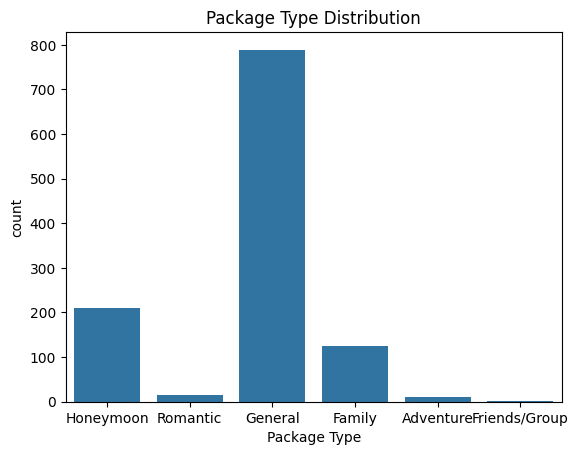

In [34]:
# plt.figure(figsize=(8,5))
sns.countplot(data = df,x = 'Package Type')
plt.title('Package Type Distribution')
plt.show()

### Discounted price distribution

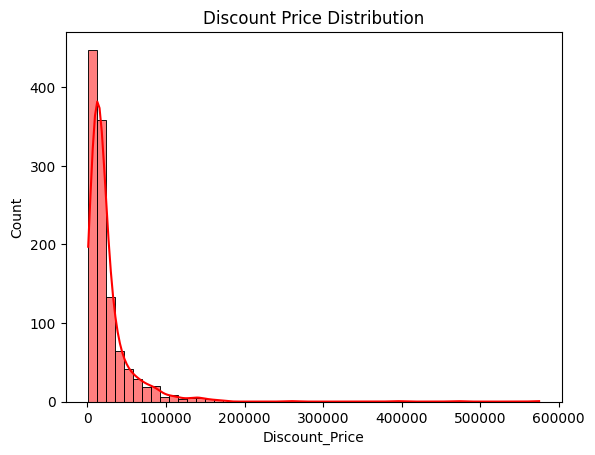

In [35]:
sns.histplot(data = df, x = 'Discount_Price',color = 'red',bins=50,kde=True)
plt.title("Discount Price Distribution")
plt.show()

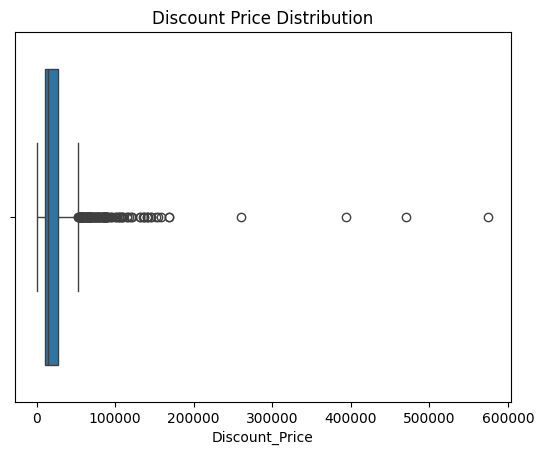

In [36]:
sns.boxplot(data = df, x = 'Discount_Price',)
plt.title("Discount Price Distribution")
plt.show()

### Days distribution


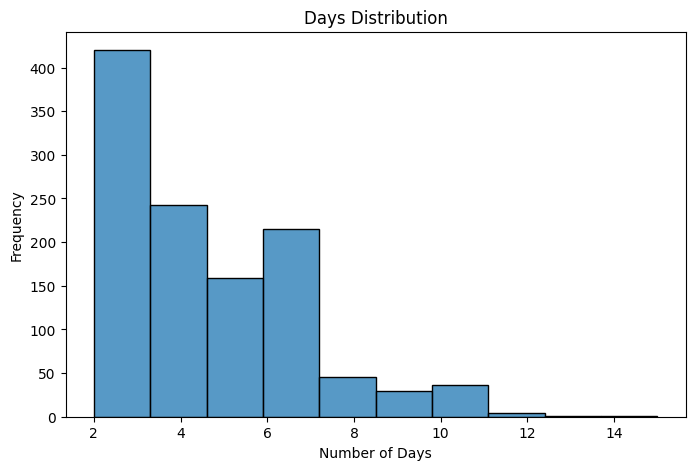

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['Days'], bins=10)

plt.title("Days Distribution")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")

plt.show()

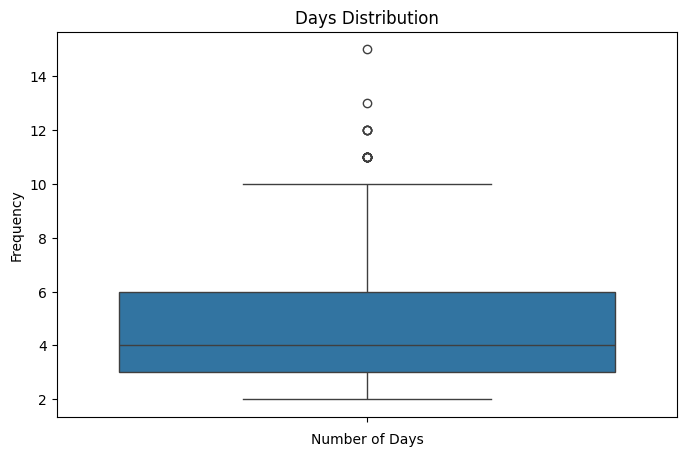

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(df['Days'], )

plt.title("Days Distribution")
plt.xlabel("Number of Days")
plt.ylabel("Frequency")

plt.show()

### original price distribution

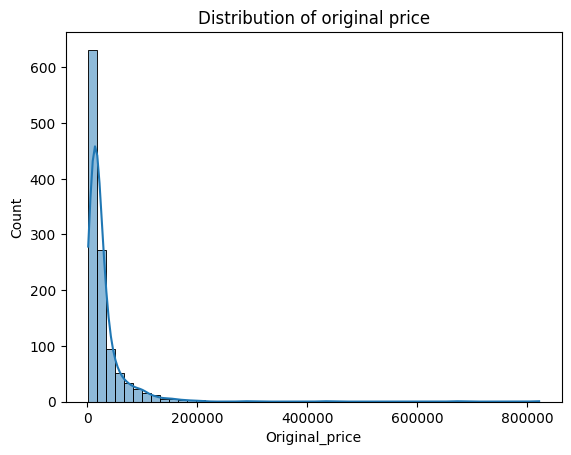

In [39]:
sns.histplot(data = df, x ="Original_price" ,bins=50,kde=True)
plt.title("Distribution of original price")
plt.show()

### Distribution of Discount

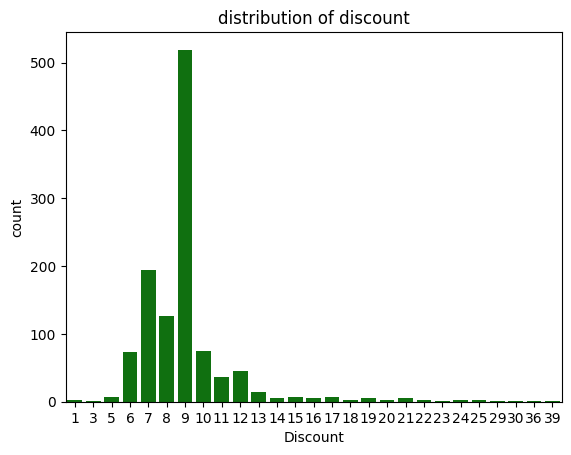

In [40]:
sns.countplot(data = df , x = 'Discount',color = 'green')
plt.title("distribution of discount")
plt.show()

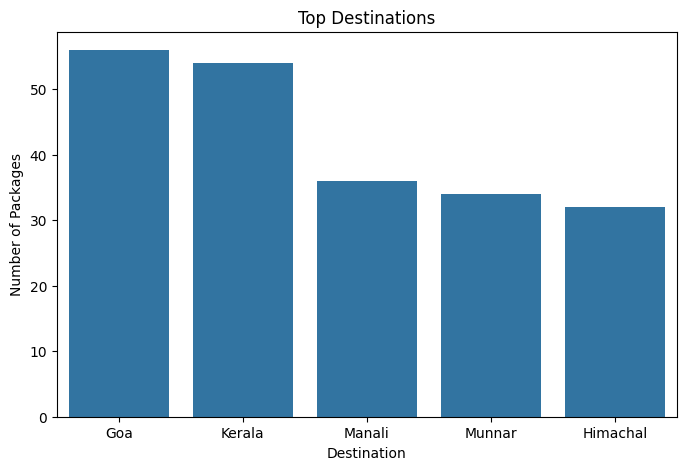

In [41]:
top_dest = df['Destination'].value_counts().head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top_dest.index, y=top_dest.values)

plt.title("Top Destinations")
plt.xlabel("Destination")
plt.ylabel("Number of Packages")

plt.show()

## 2. Bivariate Analysis

#### Package Type vs Discount"

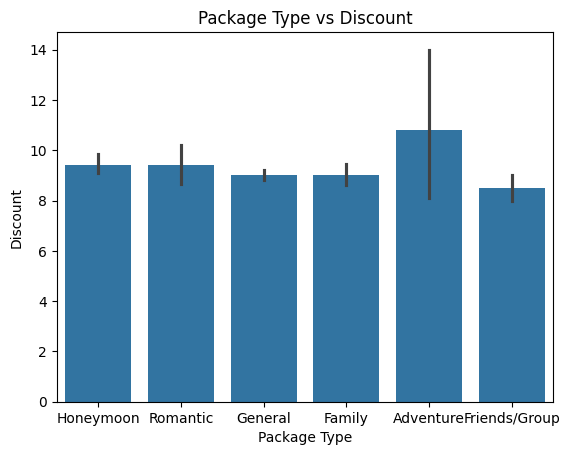

In [42]:
sns.barplot(data = df , x = 'Package Type' , y = 'Discount')
plt.title("Package Type vs Discount")
plt.show() 

#### Days vs Discount

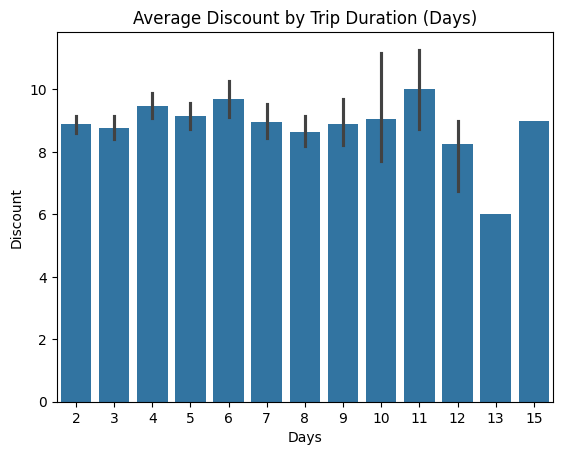

In [43]:
sns.barplot(data=df,x="Days", y= "Discount")
plt.title("Average Discount by Trip Duration (Days)")
plt.show()
#Insight: Do longer trips get more discount?

#### Package Type vs Discount_price

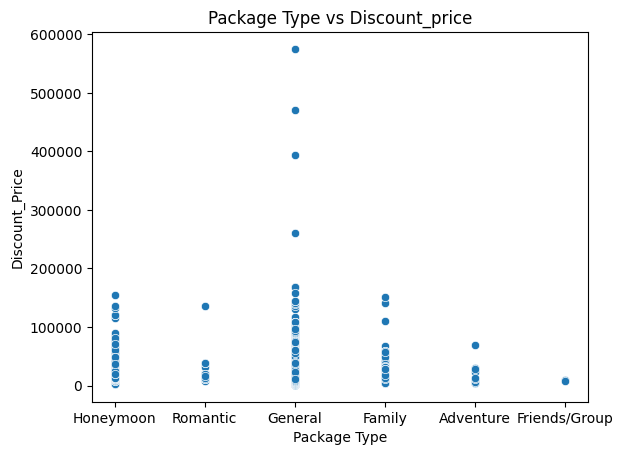

In [44]:
sns.scatterplot(data = df  , x = 'Package Type', y = "Discount_Price")
plt.title("Package Type vs Discount_price")
plt.show()

### Price vs Days


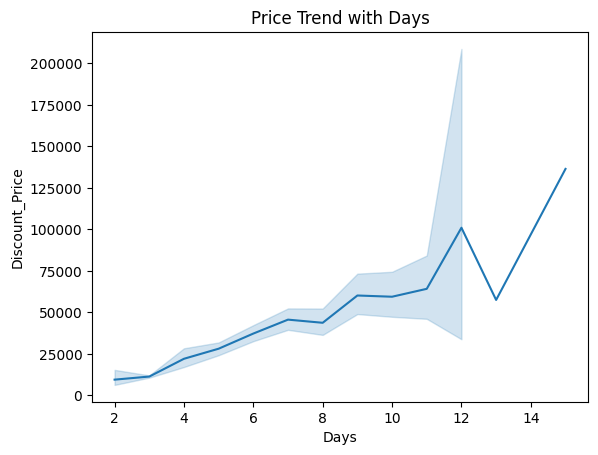

In [45]:

sns.lineplot(data=df, x='Days', y='Discount_Price')

plt.title("Price Trend with Days")
plt.show()

#### Nights vs Price

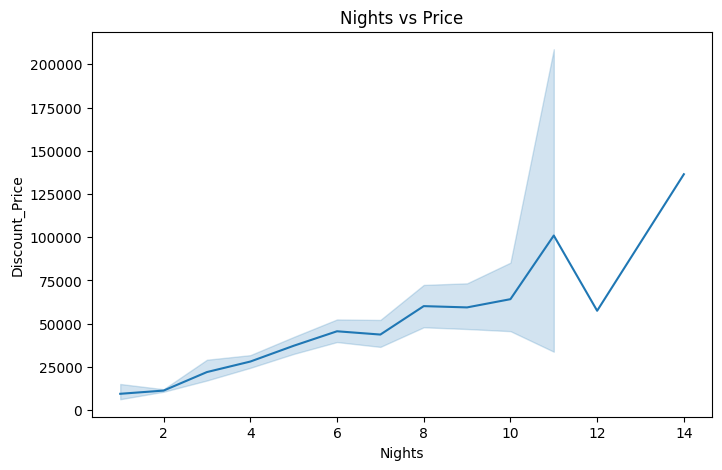

In [46]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Nights', y='Discount_Price', data=df)
plt.title("Nights vs Price")
plt.show()
#Insight: More nights = higher price?

#### Package Type vs Days


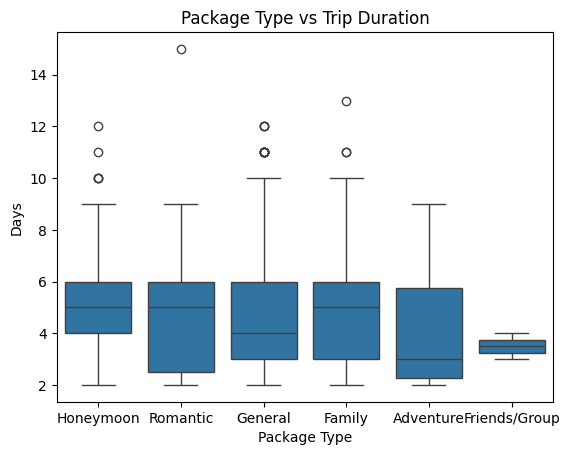

In [47]:
sns.boxplot(data =df , x = 'Package Type' , y= 'Days')
plt.title("Package Type vs Trip Duration")
plt.show()
#Insight: Which package type has longer trips

#### Average Price by Package Typ

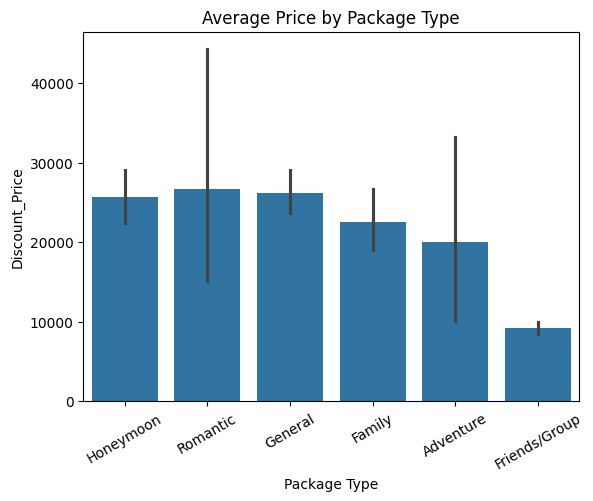

In [48]:
sns.barplot(data=df, x='Package Type', y='Discount_Price')

plt.title("Average Price by Package Type")
plt.xticks(rotation=30)
plt.show()

## Multivariate Analysis

#### Price vs Days vs Package Type

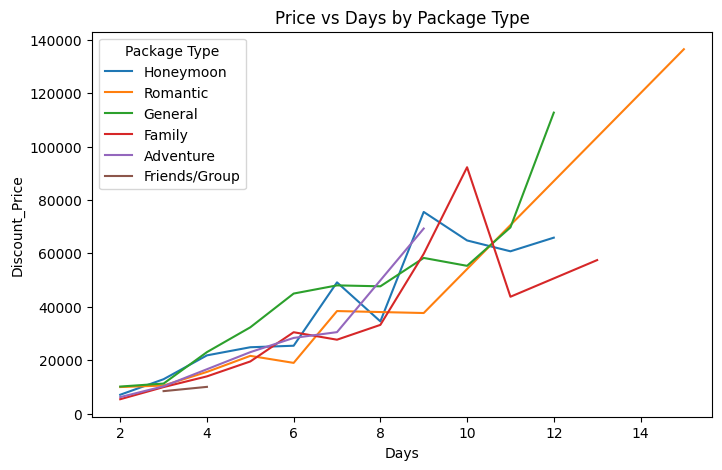

In [49]:
plt.figure(figsize=(8,5))
sns.lineplot(data = df , x = "Days", y="Discount_Price", hue='Package Type',errorbar=None)
plt.title("Price vs Days by Package Type")
plt.show()
#Insight:

#How price changes with days
#Difference between package types

#### Correlation Heatmap

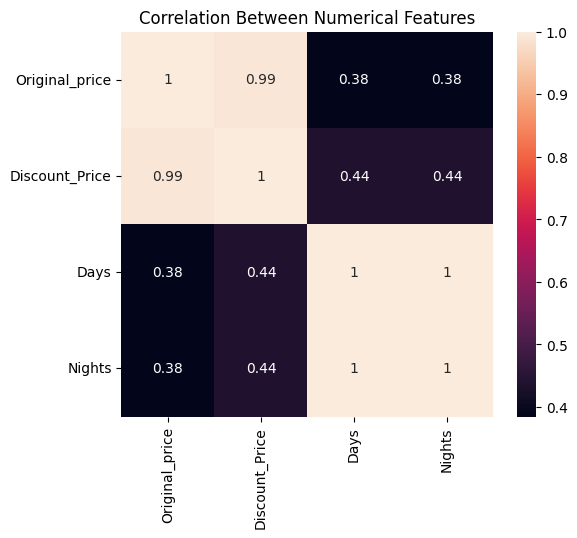

In [50]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Original_price','Discount_Price','Days','Nights']].corr(), annot=True)

plt.title("Correlation Between Numerical Features")
plt.show()

#insight:

#Relationship between variables
#Strong/weak correlations

#### Discount Price vs Days vs Destination (Top 10)

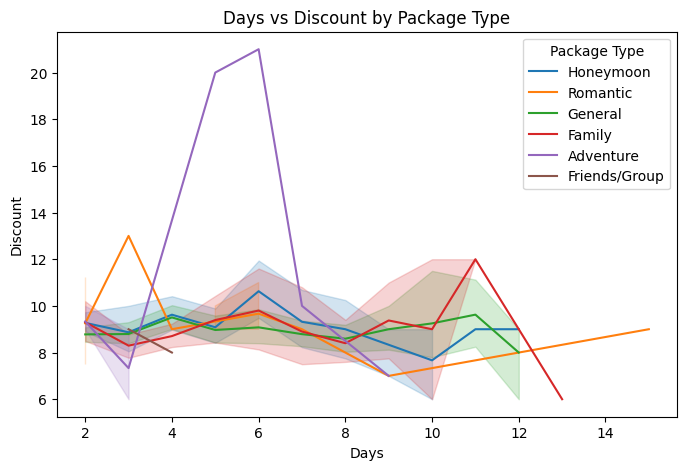

In [56]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Days', y='Discount',
                hue='Package Type', data=df)

plt.title("Days vs Discount by Package Type")
plt.show()
#Insight:

#Which destination gives better deals
#Price variation with duration

### Outlier Detection in Discount Price using IQR Method

In [52]:
q1 = df['Discount_Price'].quantile(0.25)
q3 = df['Discount_Price'].quantile(0.75)

iqr = q3-q1

lower=q1-1.5*iqr
upper= q3+1.5*iqr


print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

outliers = df[(df['Discount_Price'] < lower) | (df['Discount_Price'] > upper)]

print("Outliers count:", outliers.shape[0])
print("Outliers :", outliers)


Q1: 10726.75
Q3: 27590.0
IQR: 16863.25
Lower Limit: -14568.125
Upper Limit: 52884.875
Outliers count: 125
Outliers :                                                    Name  Discount  \
28                    Colorful Rajasthan Family Package        11   
31    Explore Darjeeling And Gangtok, The Gem Of Nor...        10   
73    Gangtok, Lachung & Darjeeling Summer Special T...         8   
227   Enigmatic Leh Ladakh Tour Packages For Enthusi...         7   
234   Adventurous Sikkim, Kalimpong & Darjeeling Tou...         6   
...                                                 ...       ...   
1064                            Do Dham Chopper Package         9   
1077         Charismatic Jammu and Kashmir Tour Package         9   
1088        Dazzling Dalhousie Sightseeing Tour Package         8   
1130  Explore The Natural Beauty Of The North East O...         7   
1135                 Alluring Kashmir Honeymoon Package         7   

      Discount_Price  Original_price  Days  Nights Des

<Axes: xlabel='Discount_Price'>

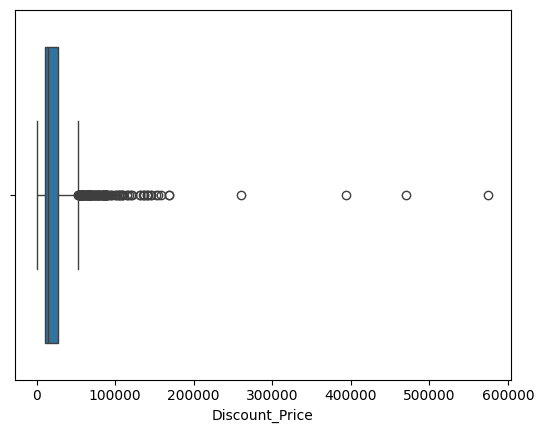

In [53]:
sns.boxplot(data=df, x='Discount_Price')

<Axes: xlabel='Original_price'>

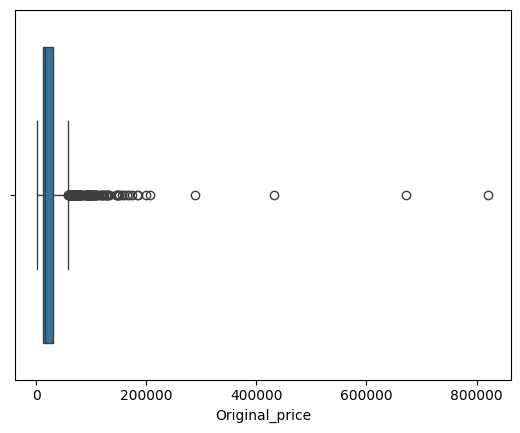

In [54]:
sns.boxplot(data=df, x='Original_price')

### Distribution of Top 5 Travel Destinations

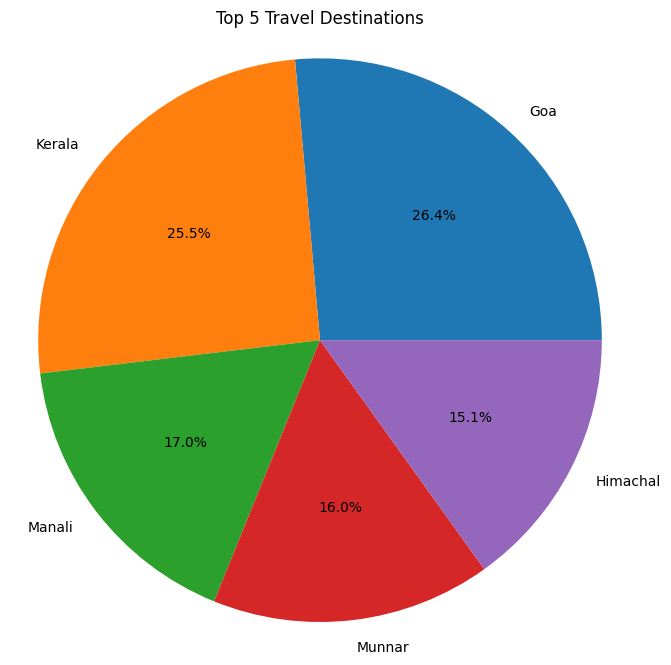

In [9]:
import matplotlib.pyplot as plt

# Count top destinations
destination_counts = df['Destination'].value_counts().head(5)

# Pie Plot
plt.figure(figsize=(8,8))
plt.pie(destination_counts, 
        labels=destination_counts.index, 
        autopct='%1.1f%%' )
       
plt.title("Top 5 Travel Destinations")
plt.axis('equal')  # Makes pie chart circular
plt.show()

### Histogram for Discount Price

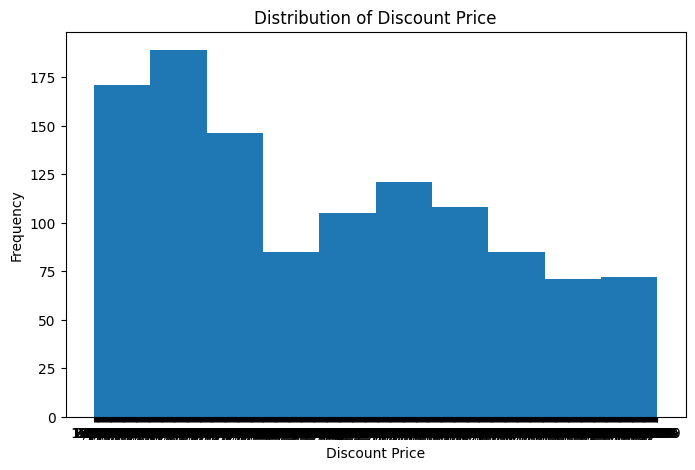

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['Discount_Price'], bins=10)

plt.title("Distribution of Discount Price")
plt.xlabel("Discount Price")
plt.ylabel("Frequency")

plt.show()